Kaplan Meier Plots

In [61]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
base_dir = "/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing/layer_norm_fusion_mlp/cancertypebatching_exp_0_phase2_10"
exp_dir = "cancertypebatching_exp_0_phase2_10"
csv_file = "global_test_risk_scores.csv"

file_path = os.path.join("/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing/layer_norm_fusion_mlp/cancertypebatching_exp_0_phase2_10/global_test_risk_scores.csv")

# Load the CSV
risk_df = pd.read_csv(file_path)
print(risk_df)

            Case ID  OS.time   OS       risk  normalized_risk  cancer_type  \
0      TCGA-L5-A43C     96.0  0.0  14.742173         0.517954            8   
1      TCGA-L5-A4OO    101.0  0.0  15.043929         0.652174            8   
2      TCGA-R6-A6L4    496.0  1.0  12.810825        -0.341102            8   
3      TCGA-E2-A154    591.0  0.0  12.899785        -0.301534            2   
4      TCGA-EW-A1OV    789.0  0.0  10.525039        -1.357812            2   
...             ...      ...  ...        ...              ...          ...   
10493  TCGA-EY-A549    605.0  0.0  50.519875         0.000963           34   
10494  TCGA-AP-A1DH   2180.0  0.0  50.783750         0.037782           34   
10495  TCGA-AP-A052    669.0  1.0  51.550957         0.144834           34   
10496  TCGA-A5-A0GV   1643.0  0.0  48.946617        -0.218560           34   
10497  TCGA-EY-A3L3    832.0  0.0  54.039127         0.492018           34   

       fold  
0         1  
1         1  
2         1  
3      

In [63]:
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test

In [64]:
risk0_df = risk_df[risk_df["cancer_type"] == 0]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25

/tmp/ipykernel_44976/40765996.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


In [65]:
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()


In [66]:
kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")



<lifelines.KaplanMeierFitter:"High Risk", fitted with 45 total observations, 22 right-censored observations>

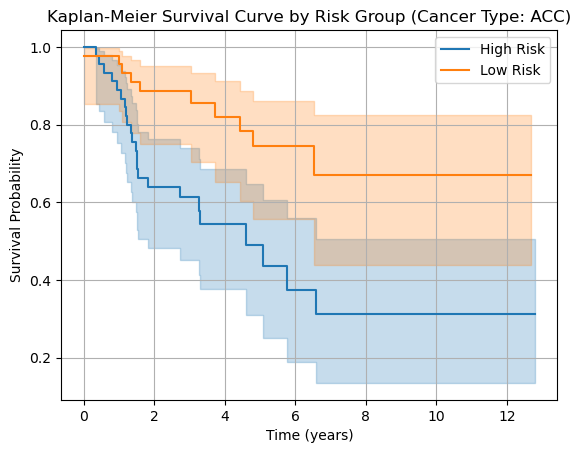

In [67]:
ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: ACC)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


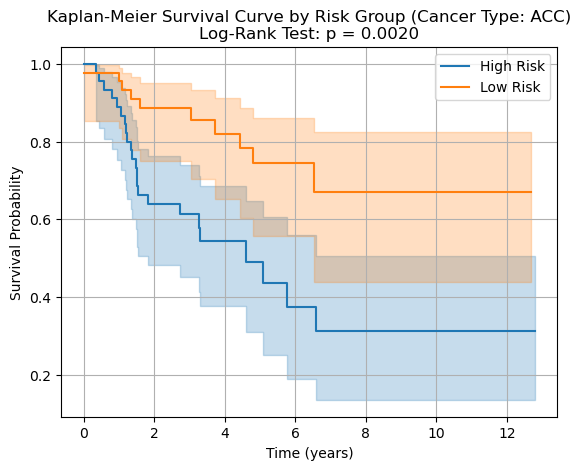

In [68]:
results = logrank_test(
    low_risk['OS.time'], high_risk['OS.time'],
    event_observed_A=low_risk['OS'], event_observed_B=high_risk['OS']
)
p_value = results.p_value

# Plot the survival curves
ax = kmf_high.plot()
kmf_low.plot(ax=ax)

# Format p-value: for extremely small values, many papers use "p < 0.001"
if p_value < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p_value:.4f}"

plt.title(f'Kaplan-Meier Survival Curve by Risk Group (Cancer Type: ACC)\nLog-Rank Test: {p_text}')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

BRCA

In [80]:
risk0_df = risk_df[risk_df["cancer_type"] == 2]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25

/tmp/ipykernel_44976/994582192.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


In [81]:
risk_df

,Case ID,OS.time,OS,risk,normalized_risk,cancer_type,fold
0,TCGA-L5-A43C,96.0,0.0,14.742173,0.517954,8,1
1,TCGA-L5-A4OO,101.0,0.0,15.043929,0.652174,8,1
2,TCGA-R6-A6L4,496.0,1.0,12.810825,-0.341102,8,1
3,TCGA-E2-A154,591.0,0.0,12.899785,-0.301534,2,1
4,TCGA-EW-A1OV,789.0,0.0,10.525039,-1.357812,2,1
...,...,...,...,...,...,...,...
10493,TCGA-EY-A549,605.0,0.0,50.519875,0.000963,34,10
10494,TCGA-AP-A1DH,2180.0,0.0,50.783750,0.037782,34,10
10495,TCGA-AP-A052,669.0,1.0,51.550957,0.144834,34,10
10496,TCGA-A5-A0GV,1643.0,0.0,48.946617,-0.218560,34,10


In [82]:
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()


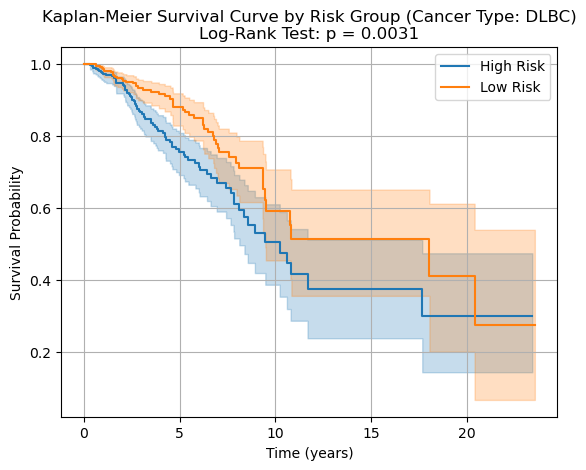

In [ ]:
kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")

results = logrank_test(
    low_risk['OS.time'], high_risk['OS.time'],
    event_observed_A=low_risk['OS'], event_observed_B=high_risk['OS']
)
p_value = results.p_value

# Plot the survival curves
ax = kmf_high.plot()
kmf_low.plot(ax=ax)

# Format p-value: for extremely small values, many papers use "p < 0.001"
if p_value < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p_value:.4f}"

plt.title(f'Kaplan-Meier Survival Curve by Risk Group (Cancer Type: BRCA)\nLog-Rank Test: {p_text}')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()


In [73]:
risk7_df = risk_df[risk_df["cancer_type"] == 17]
risk7_df['OS.time'] = risk7_df['OS.time'] / 365.25

/tmp/ipykernel_44976/229297027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk7_df['OS.time'] = risk7_df['OS.time'] / 365.25


In [74]:
median_risk = risk7_df['normalized_risk'].median()
high_risk = risk7_df[risk7_df['normalized_risk'] >= median_risk]
low_risk = risk7_df[risk7_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()


In [75]:
kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")



<lifelines.KaplanMeierFitter:"High Risk", fitted with 264 total observations, 182 right-censored observations>

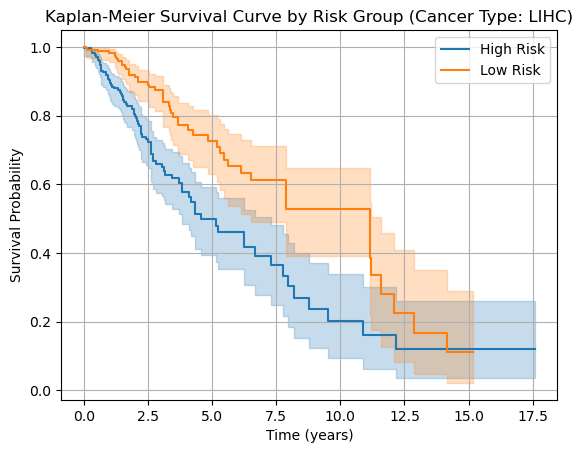

In [76]:
ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: LIHC)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


Messed up kaplans

/tmp/ipykernel_44976/887510339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


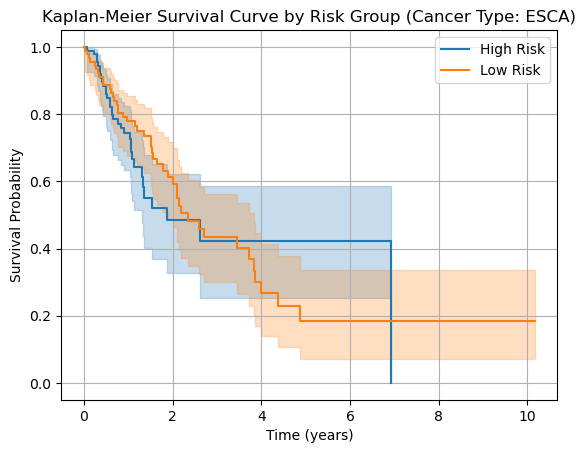

In [77]:
risk0_df = risk_df[risk_df["cancer_type"] == 8]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")

ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: ESCA)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


/tmp/ipykernel_44976/3090232519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


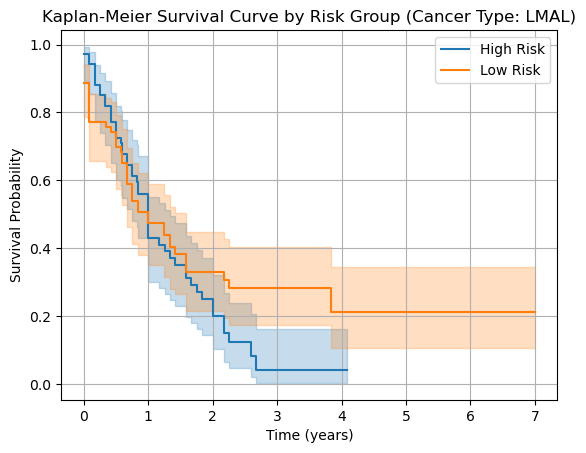

In [78]:
risk0_df = risk_df[risk_df["cancer_type"] == 15]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")

ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: LMAL)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()
